# Bayesian Counterfactual Analysis: Life Expectancy Gap

This notebook performs counterfactual analysis for the Life Expectancy gap using the Bayesian panel model results. For each gap predictor, we compute what would happen to a country's predicted Life Expectancy gap if we adjusted that predictor to the best attainable value observed across all country-years.

## Overview

**Counterfactual Question**: What would happen to a country's Life Expectancy gap if we adjusted a specific gap predictor to the best attainable value (while keeping all other predictors constant)?

**Key Features**:
- Uses posterior distributions (not just point estimates) to quantify uncertainty
- Accounts for country-specific intercepts (α_i) when making predictions
- Provides credible intervals (94% HDI) for all counterfactual predictions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path
import json

from utils import (
    decorate, configure_plot_style, AIBM_COLORS,
    code_to_who_country, codes_to_country_names,
    write_html_table
)
from counterfactual_utils import (
    compute_importance_summary,
    create_counterfactual_visualizations,
    plot_counterfactual_forest,
    plot_counterfactual_by_type,
    plot_counterfactual_bar,
    format_counterfactual_table,
    compute_gap_extremes,
    counterfactual_predictions_bayesian,
    plot_predicted_vs_actual_over_time
)

configure_plot_style()

## Load Saved Model Results

In [3]:
# ============================================================================
# MODEL CONFIGURATION: Select which model version to use
# ============================================================================
# Options:
#   '2019_nocovid' - Pre-COVID baseline (2000-2019, no COVID-19 predictor)
#   '2021_covid'   - Extended analysis (2000-2021, includes COVID-19 predictor)
#   'legacy'       - Legacy model (older format, if exists)
MODEL_VERSION = '2019_nocovid'  
MODEL_VERSION = '2021_covid'  

# Map model version to suffix
MODEL_SUFFIX_MAP = {
    '2019_nocovid': '_nomid_nogrw_y2019_nocovid',
    '2021_covid': '_nomid_nogrw_y2021_covid',
    'legacy': '_nomid_nogrw'  # Older format, may not exist
}

# Get the suffix for the selected model version
MODEL_SUFFIX = MODEL_SUFFIX_MAP.get(MODEL_VERSION, '_nomid_nogrw_y2019_nocovid')

print(f"Model Configuration:")
print(f"  Selected version: {MODEL_VERSION}")
print(f"  Model suffix: {MODEL_SUFFIX}")

# Path to saved results
results_dir = Path('../data/bayesian_model_results')

Model Configuration:
  Selected version: 2021_covid
  Model suffix: _nomid_nogrw_y2021_covid


In [4]:
# Load metadata
meta_filename = results_dir / f'metadata_le{MODEL_SUFFIX}.json'
with open(meta_filename, 'r') as f:
    metadata = json.load(f)

print("Metadata loaded:")
print(f"  Countries: {len(metadata['countries'])}")
print(f"  Years: {len(metadata['years'])} (range: {min(metadata['years'])}-{max(metadata['years'])})")
print(f"  Predictors: {len(metadata['predictors'])}")
print(f"  Model config: {metadata['model_config']}")

Metadata loaded:
  Countries: 37
  Years: 22 (range: 2000-2021)
  Predictors: 12
  Model config: {'mid_predictors_included': [], 'include_year_effects': False, 'countries_excluded': ['TUR'], 'cutoff_year': 2021, 'include_covid_data': True}


In [5]:
# Load trace (posterior samples)
trace_filename = results_dir / f'trace_le{MODEL_SUFFIX}.nc'
trace = az.from_netcdf(trace_filename)
print(f"\nTrace loaded from: {trace_filename}")
print(f"Number of chains: {trace.posterior.sizes['chain']}")
print(f"Number of draws per chain: {trace.posterior.sizes['draw']}")
print(f"Total samples: {trace.posterior.sizes['chain'] * trace.posterior.sizes['draw']}")


Trace loaded from: ../data/bayesian_model_results/trace_le_nomid_nogrw_y2021_covid.nc
Number of chains: 4
Number of draws per chain: 1000
Total samples: 4000


In [6]:
# Load panel dataset (same as HALE - contains both HALE_gap and LE_gap)
panel_filename = results_dir / f'panel_dataset{MODEL_SUFFIX}.h5'
panel_df = pd.read_hdf(panel_filename, key='panel_data')
print(f"\nPanel dataset loaded from: {panel_filename}")
print(f"Shape: {panel_df.shape}")
print(f"Columns: {list(panel_df.columns)[:10]}...")  # Show first 10 columns


Panel dataset loaded from: ../data/bayesian_model_results/panel_dataset_nomid_nogrw_y2021_covid.h5
Shape: (814, 28)
Columns: ['country', 'Year', 'HALE_gap', 'LE_gap', 'Mid_Alcohol', 'Gap_Alcohol', 'Mid_Suicide', 'Gap_Suicide', 'Mid_Homicide', 'Gap_Homicide']...


In [7]:
# Verify data alignment
print("\nData verification:")
print(f"  Panel countries: {panel_df['country'].nunique()}")
print(f"  Metadata countries: {len(metadata['countries'])}")
print(f"  Panel years: {sorted(panel_df['Year'].unique())[:5]}...")  # Show first 5
print(f"  Metadata years: {metadata['years'][:5]}...")  # Show first 5


Data verification:
  Panel countries: 37
  Metadata countries: 37
  Panel years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004)]...
  Metadata years: [2000, 2001, 2002, 2003, 2004]...


## Extract Transformation Parameters

In [8]:
# Extract standardization parameters (convert back to numpy arrays)
X_mean = np.array(metadata['X_mean'])
X_std = np.array(metadata['X_std'])
y_mean = metadata['y_mean']

# Extract predictor names and country/year mappings
predictors = metadata['predictors']
countries = np.array(metadata['countries'])
years = np.array(metadata['years'])

# Create indexers for country and year
country_to_idx = {c: i for i, c in enumerate(countries)}
year_to_idx = {y: i for i, y in enumerate(years)}

print("Transformation parameters:")
print(f"  X_mean shape: {X_mean.shape}")
print(f"  X_std shape: {X_std.shape}")
print(f"  y_mean: {y_mean:.4f} years")
print(f"  Number of predictors: {len(predictors)}")

Transformation parameters:
  X_mean shape: (12,)
  X_std shape: (12,)
  y_mean: 5.5517 years
  Number of predictors: 12


## Gap Extremes Table

Find the minimum and maximum gap values for each gap predictor across all country-years:

In [9]:
# Compute extremes for each gap predictor using helper function
gap_extremes = compute_gap_extremes(panel_df)

# Display as DataFrame
gap_extremes_df = pd.DataFrame(gap_extremes).T
gap_extremes_df = gap_extremes_df.sort_index()
print(f"Found {len(gap_extremes)} gap predictors")
gap_extremes_df

Found 12 gap predictors


,min_gap,min_country,min_year,max_gap,max_country,max_year
Gap_Alcohol,0.232216,COL,2016,33.115885,EST,2005
Gap_COVID,-15.202926,SVN,2020,151.884331,MEX,2020
Gap_Cardiovascular,-191.111845,LVA,2021,38.467765,ISL,2004
Gap_ChronicRespiratory,-19.634566,ISL,2021,44.704105,BEL,2000
Gap_Diabetes,-11.964442,LVA,2021,6.808071,USA,2021
Gap_DrugDisorder,0.002801,JPN,2013,22.474917,USA,2021
Gap_Homicide,-0.062157,NOR,2019,140.488807,COL,2002
Gap_LiverDisease,0.728846,ISL,2001,65.249061,HUN,2000
Gap_Neoplasms,-2.93991,COL,2021,139.183482,PRT,2021
Gap_RoadTraffic,1.916296,ISL,2017,31.35789,LVA,2000


## Counterfactual Prediction Function

The counterfactual prediction function is imported from `counterfactual_utils`. It computes what would happen to a country's predicted gap if we adjusted a specific gap predictor to the best attainable value observed across all country-years.

## Test Counterfactual Function

Test the function with a simple example:

In [10]:
# Test with USA in 2019, Alcohol gap
test_country = 'USA'
test_year = 2019
test_predictor = 'Gap_Alcohol'

result = counterfactual_predictions_bayesian(
    test_country, test_year, test_predictor,
    trace, metadata, panel_df, gap_extremes,
    country_to_idx, year_to_idx
)

print(f"Counterfactual Analysis: {code_to_who_country.get(test_country, test_country)} ({test_country}) in {test_year}")
print(f"Indicator: {result['indicator']}")
print(f"\nCurrent {result['indicator']} gap (predictor): {result['current_gap']:.3f}")
print(f"Note: This is the gap for the {result['indicator']} predictor, not the Life Expectancy gap itself")
if result['target_country']:
    print(f"Target gap: {result['target_gap']:.3f} (from {code_to_who_country.get(result['target_country'], result['target_country'])} in {result['target_year']})")
else:
    print(f"Target gap: {result['target_gap']:.3f} (set to zero)")
print(f"\nPredicted Life Expectancy gap (original, before counterfactual):")
print(f"  Mean: {result['original_summary']['mean']:.3f} years")
print(f"  94% HDI: [{result['original_summary']['hdi_3%']:.3f}, {result['original_summary']['hdi_97%']:.3f}]")
print(f"\nPredicted Life Expectancy gap (counterfactual, after adjustment):")
print(f"  Mean: {result['counterfactual_summary']['mean']:.3f} years")
print(f"  94% HDI: [{result['counterfactual_summary']['hdi_3%']:.3f}, {result['counterfactual_summary']['hdi_97%']:.3f}]")
print(f"\nChange in Life Expectancy gap:")
print(f"  Mean: {result['change_summary']['mean']:.3f} years")
print(f"  94% HDI: [{result['change_summary']['hdi_3%']:.3f}, {result['change_summary']['hdi_97%']:.3f}]")

Counterfactual Analysis: United States (USA) in 2019
Indicator: Alcohol

Current Alcohol gap (predictor): 5.544
Note: This is the gap for the Alcohol predictor, not the Life Expectancy gap itself
Target gap: 0.232 (from Colombia in 2016)

Predicted Life Expectancy gap (original, before counterfactual):
  Mean: 4.552 years
  94% HDI: [4.386, 4.708]

Predicted Life Expectancy gap (counterfactual, after adjustment):
  Mean: 4.404 years
  94% HDI: [4.238, 4.592]

Change in Life Expectancy gap:
  Mean: -0.148 years
  94% HDI: [-0.208, -0.087]


## Spot Check: Actual vs Predicted Life Expectancy Gap for USA (2019)

Verify that the predicted Life Expectancy gap matches expectations and compare with the actual value:

In [11]:
# Get actual Life Expectancy gap for USA in 2019
usa_2019_mask = (panel_df['country'] == 'USA') & (panel_df['Year'] == 2019)
if usa_2019_mask.any():
    actual_le_gap = panel_df[usa_2019_mask]['LE_gap'].iloc[0]
    print(f"Actual Life Expectancy gap for USA (2019): {actual_le_gap:.3f} years")
else:
    print("Warning: No data found for USA in 2019")
    actual_le_gap = None

# Compute predicted Life Expectancy gap using the same method as counterfactual function
# Get current country-year row
current_row = panel_df[usa_2019_mask].iloc[0]

# Get transformation parameters
X_mean = np.array(metadata['X_mean'])
X_std = np.array(metadata['X_std'])
y_mean = metadata['y_mean']
predictors = metadata['predictors']
countries = np.array(metadata['countries'])

# Get country index
country_idx_val = country_to_idx['USA']

# Build predictor vector (standardized)
X_current = np.array([current_row[p] for p in predictors])
X_current_std = (X_current - X_mean) / X_std

# Extract posterior samples
beta_samples = trace.posterior['beta'].values.reshape(-1, len(predictors))
alpha_samples = trace.posterior['alpha'].values.reshape(-1, len(countries))

# Compute predictions for each posterior sample
alpha_i_samples = alpha_samples[:, country_idx_val]
pred_centered = alpha_i_samples + np.dot(X_current_std, beta_samples.T)
pred_original = pred_centered + y_mean

# Compute summary
pred_mean = np.mean(pred_original)
pred_hdi = az.hdi(pred_original, hdi_prob=0.94)

print(f"\nPredicted Life Expectancy gap for USA (2019):")
print(f"  Mean: {pred_mean:.3f} years")
print(f"  94% HDI: [{pred_hdi[0]:.3f}, {pred_hdi[1]:.3f}]")

if actual_le_gap is not None:
    residual = actual_le_gap - pred_mean
    print(f"\nResidual (Actual - Predicted): {residual:.3f} years")
    print(f"  This should match the residual from the residual analysis section")
    print(f"  (within rounding error)")
    
# Also verify this matches the counterfactual function's original prediction
# (using the test result from above)
print(f"\n" + "="*60)
print("Verification: Compare with counterfactual function output")
print("="*60)
print(f"Counterfactual function 'original_prediction' mean: {result['original_summary']['mean']:.3f} years")
print(f"Spot check computed prediction mean: {pred_mean:.3f} years")
print(f"Difference: {abs(result['original_summary']['mean'] - pred_mean):.6f} years")
print(f"  (Should be < 0.001, i.e., essentially identical)")

Actual Life Expectancy gap for USA (2019): 4.450 years

Predicted Life Expectancy gap for USA (2019):
  Mean: 4.552 years
  94% HDI: [4.386, 4.708]

Residual (Actual - Predicted): -0.102 years
  This should match the residual from the residual analysis section
  (within rounding error)

Verification: Compare with counterfactual function output
Counterfactual function 'original_prediction' mean: 4.552 years
Spot check computed prediction mean: 4.552 years
Difference: 0.000000 years
  (Should be < 0.001, i.e., essentially identical)


## Compute Importance Measures

Load or compute importance measures to sort counterfactuals by importance:

In [12]:
# Compute importance summary using helper function
importance_summary = compute_importance_summary(trace, metadata)
importance_summary

,Predictor,Importance_mean,Importance_hdi_3%,Importance_hdi_97%
6,Gap_Neoplasms,13.855153,9.538447,18.176193
4,Gap_Cardiovascular,7.188747,5.137919,9.199102
2,Gap_Homicide,6.081192,5.405525,6.755690
1,Gap_Suicide,4.695603,3.813657,5.591313
7,Gap_ChronicRespiratory,3.906169,3.024111,4.755902
3,Gap_RoadTraffic,2.583946,2.262962,2.894916
8,Gap_LiverDisease,2.396345,1.756932,3.032287
9,Gap_UnintentionalInjury,1.893683,0.473484,3.338216
11,Gap_COVID,1.137265,0.918804,1.354273
0,Gap_Alcohol,1.067919,0.625811,1.501251


## Counterfactual Analysis for All Predictors: United States (2019)

Generate counterfactual predictions for all gap predictors for USA in 2019:

In [13]:
# Generate counterfactual results for all predictors
gap_predictors = [col for col in panel_df.columns if col.startswith('Gap_')]
counterfactual_results = []

for gap_pred in gap_predictors:
    try:
        result = counterfactual_predictions_bayesian(
            'USA', 2019, gap_pred,
            trace, metadata, panel_df, gap_extremes,
            country_to_idx, year_to_idx
        )
        counterfactual_results.append(result)
    except (KeyError, ValueError) as e:
        print(f"Warning: Skipping {gap_pred}: {e}")
        continue

# Format into table using helper function
usa_counterfactuals, usa_counterfactuals_full = format_counterfactual_table(
    counterfactual_results, importance_summary, code_to_who_country, target_name='Life Expectancy gap'
)

print("Counterfactual Analysis: United States (USA) in 2019")
print("="*80)
print(f"\nNumber of indicators analyzed: {len(usa_counterfactuals)}")
print(f"\nResults (sorted by importance):")
usa_counterfactuals

Counterfactual Analysis: United States (USA) in 2019

Number of indicators analyzed: 12

Results (sorted by importance):


,Indicator,Current gap,Target gap,Target Country-Year,Change in Life Expectancy gap (years)
6,Neoplasms,25.657586,0.000000,,"-0.243 [-0.322, -0.170]"
4,Cardiovascular,19.396726,0.000000,,"0.105 [0.073, 0.132]"
2,Homicide,7.291020,0.000000,,"-0.237 [-0.264, -0.212]"
1,Suicide,17.255473,4.046745,Greece (2002),"-0.645 [-0.771, -0.528]"
7,ChronicRespiratory,-5.823940,0.000000,,"0.200 [0.156, 0.244]"
3,RoadTraffic,11.161247,1.916296,Iceland (2017),"-0.685 [-0.776, -0.610]"
8,LiverDisease,9.053963,0.728846,Iceland (2001),"-0.208 [-0.266, -0.156]"
9,UnintentionalInjury,5.255187,0.000000,,"-0.041 [-0.074, -0.011]"
11,COVID,0.000000,151.884331,Mexico (2020),"1.473 [1.194, 1.757]"
0,Alcohol,5.543927,0.232216,Colombia (2016),"-0.148 [-0.208, -0.087]"


In [14]:
# Write counterfactual table to HTML
output_filename = f'jb/tables/counterfactuals_usa_2019_le_bayesian.html'
write_html_table(usa_counterfactuals, output_filename)
print(f"Saved counterfactual table to: {output_filename}")

Saved counterfactual table to: jb/tables/counterfactuals_usa_2019_le_bayesian.html


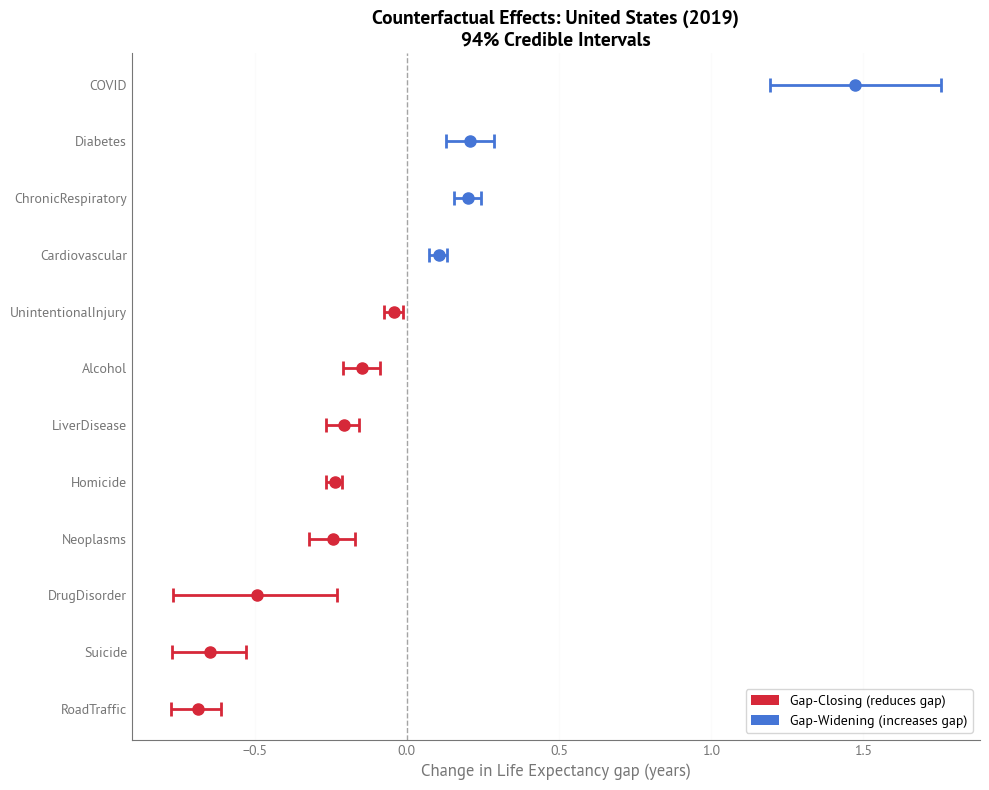

'jb/figs/counterfactual_effects_usa_2019_le_bayesian.png'

In [15]:
# Forest Plot: All Indicators
plot_counterfactual_forest(
    counterfactual_results,
    output_prefix='counterfactual_effects_usa_2019_le',
    target_name='Life Expectancy gap'
)

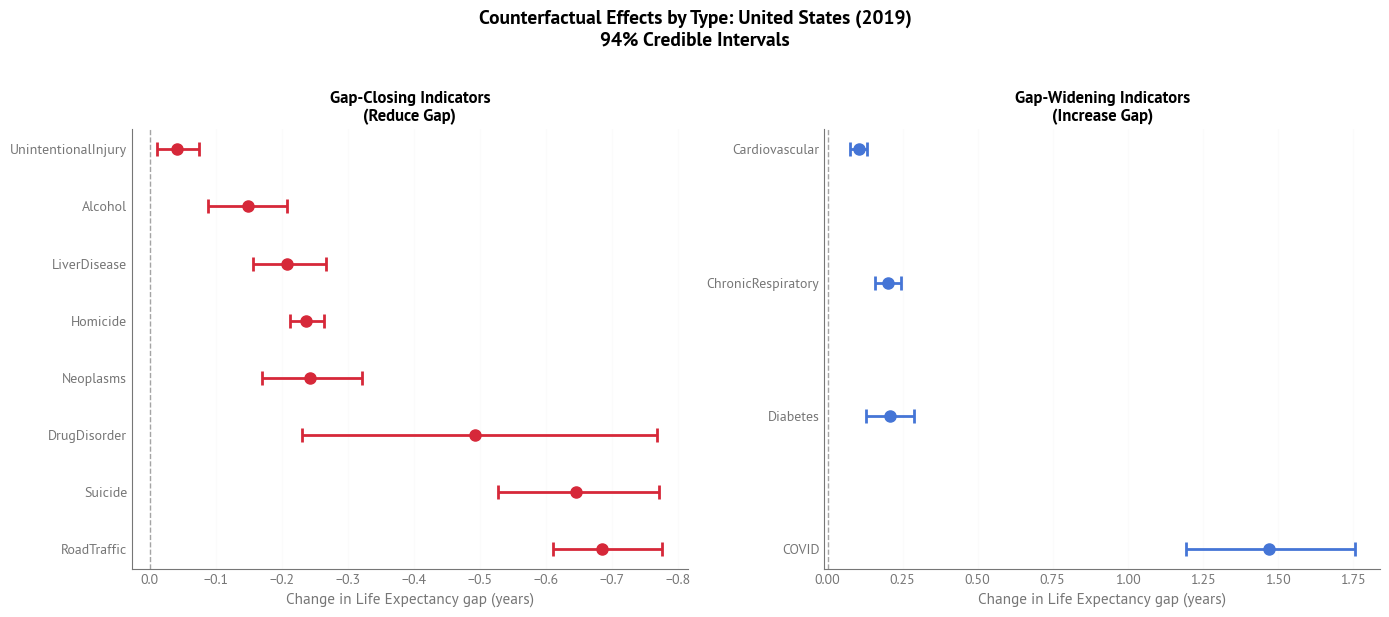

'jb/figs/counterfactual_effects_usa_2019_le_by_type_bayesian.png'

In [16]:
# Two-Panel Plot: Gap-Closing vs Gap-Widening
plot_counterfactual_by_type(
    counterfactual_results,
    output_prefix='counterfactual_effects_usa_2019_le',
    target_name='Life Expectancy gap'
)

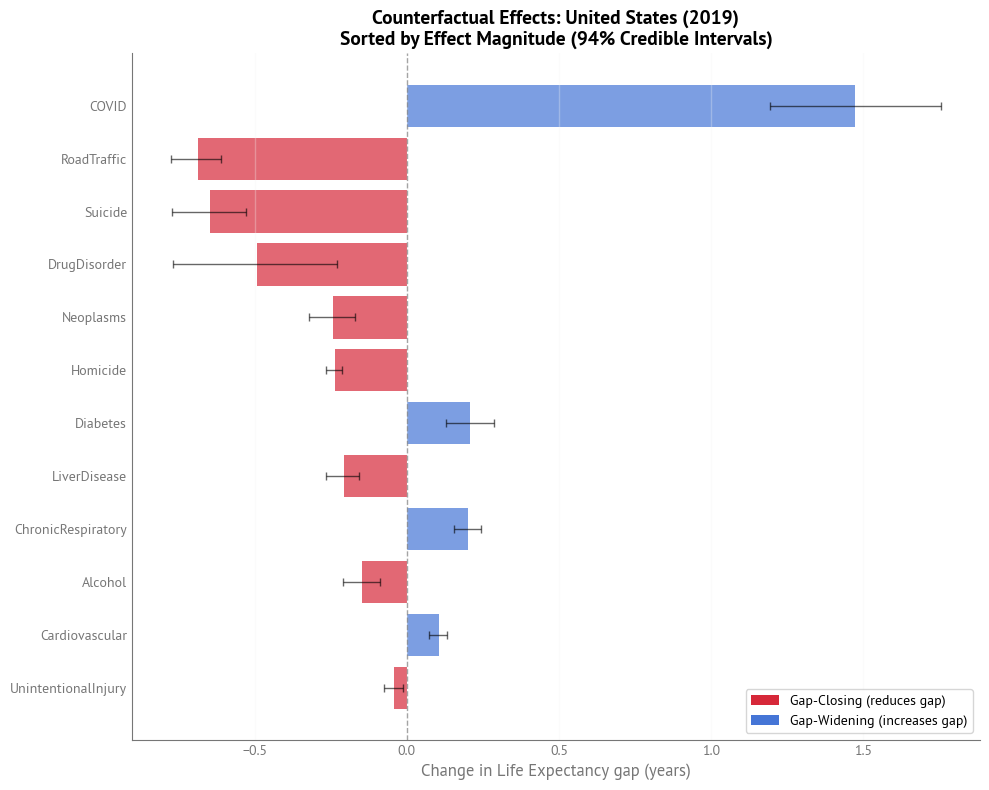

'jb/figs/counterfactual_effects_usa_2019_le_bar_bayesian.png'

In [17]:
# Bar Chart: Sorted by Magnitude
plot_counterfactual_bar(
    counterfactual_results,
    output_prefix='counterfactual_effects_usa_2019_le',
    target_name='Life Expectancy gap'
)

## Aggregate Effects

Compute aggregate effects (sum of gap-closing and gap-widening indicators):

In [18]:
# Separate gap-closing (negative change) and gap-widening (positive change) indicators
gap_closing = usa_counterfactuals_full[usa_counterfactuals_full['Change mean'] < 0].copy()
gap_widening = usa_counterfactuals_full[usa_counterfactuals_full['Change mean'] > 0].copy()

print("Gap-Closing Indicators (negative change = reduces Life Expectancy gap):")
print(f"  Number of indicators: {len(gap_closing)}")
if len(gap_closing) > 0:
    total_closing = gap_closing['Change mean'].sum()
    print(f"  Total effect (sum of means): {total_closing:.3f} years")
    print(f"  Indicators: {', '.join(gap_closing['Indicator'].tolist())}")

print(f"\nGap-Widening Indicators (positive change = increases Life Expectancy gap):")
print(f"  Number of indicators: {len(gap_widening)}")
if len(gap_widening) > 0:
    total_widening = gap_widening['Change mean'].sum()
    print(f"  Total effect (sum of means): {total_widening:.3f} years")
    print(f"  Indicators: {', '.join(gap_widening['Indicator'].tolist())}")

# Compute net effect
net_effect = usa_counterfactuals_full['Change mean'].sum()
print(f"\nNet Effect (all indicators combined): {net_effect:.3f} years")
print(f"\nNote: These are point estimates (means). For uncertainty quantification,")
print(f"      we would need to compute the posterior distribution of the sum.")

Gap-Closing Indicators (negative change = reduces Life Expectancy gap):
  Number of indicators: 8
  Total effect (sum of means): -2.700 years
  Indicators: Neoplasms, Homicide, Suicide, RoadTraffic, LiverDisease, UnintentionalInjury, Alcohol, DrugDisorder

Gap-Widening Indicators (positive change = increases Life Expectancy gap):
  Number of indicators: 4
  Total effect (sum of means): 1.986 years
  Indicators: Cardiovascular, ChronicRespiratory, COVID, Diabetes

Net Effect (all indicators combined): -0.714 years

Note: These are point estimates (means). For uncertainty quantification,
      we would need to compute the posterior distribution of the sum.


## Predicted vs Actual Life Expectancy Gap Over Time: United States

Plot the predicted vs actual Life Expectancy gap over time for the United States to visualize model fit:

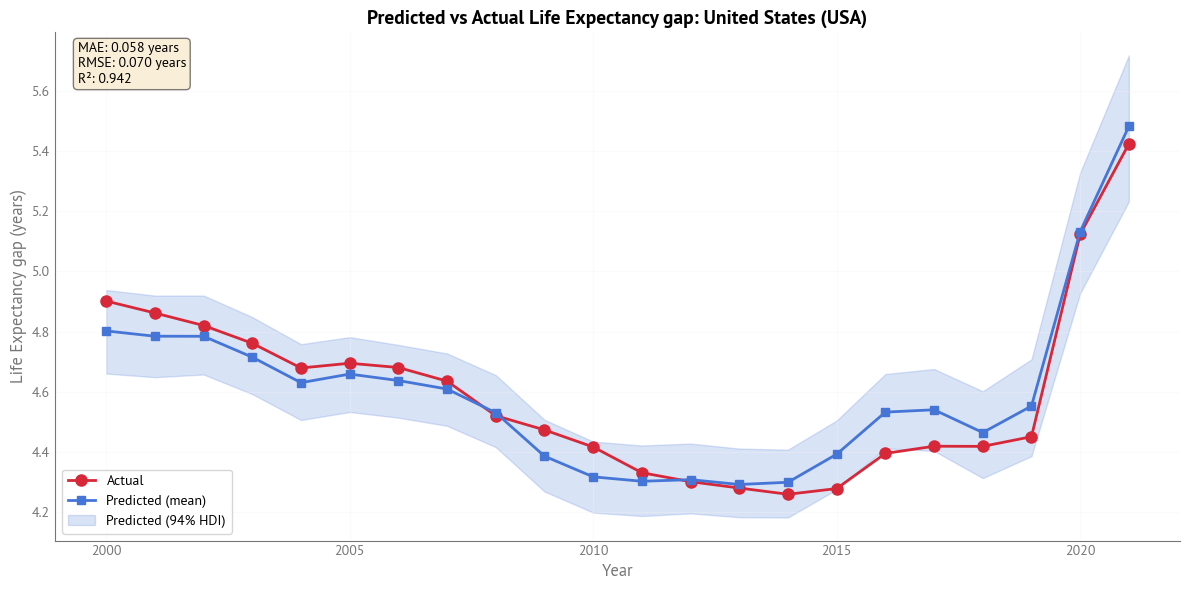

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Predicted vs Actual Life Expectancy gap: United States (USA)'}, xlabel='Year', ylabel='Life Expectancy gap (years)'>)

In [19]:
# Plot predicted vs actual Life Expectancy gap for USA over time
plot_predicted_vs_actual_over_time(
    country='USA',
    trace=trace,
    metadata=metadata,
    panel_df=panel_df,
    country_to_idx=country_to_idx,
    target_name='Life Expectancy gap',
    target_col='LE_gap',
    output_filename='jb/figs/predicted_vs_actual_le_usa.png'
)